# import

In [72]:
import os
import re
import gzip
import json
from glob import glob
import laspy
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pprint import pprint
from PIL import Image, ImageDraw
import cv2
%matplotlib inline

# configs

In [31]:
TRAINING_DATA_ROOT = "/home/ec2-user/AD_challenge/CAPSTONE_DESIGN_1/carla_garage/training_data/DynamicObjectCrossing/Town03_Rep0_Town03_Scenario3_3_route0_11_08_19_10_56"
BENCH_ROOT = Path("./carla_garage/results/bench2drive220")

COLLISION_KEYS = ["collisions_vehicle", "collisions_pedestrian", "collisions_layout"]
COLLISION_PATTERN = re.compile(
    r"type=(?P<type>.+?) and id=(?P<object_id>\d+) at "
    r"\(x=(?P<x>-?\d+(?:\.\d+)?), y=(?P<y>-?\d+(?:\.\d+)?), z=(?P<z>-?\d+(?:\.\d+)?)\)"
)

# Utils

In [66]:
# 숫자 기준 정렬 함수
def get_sorted_images(folder):
    return sorted(
        glob(os.path.join(folder, "*.png")),
        key=lambda x: int(os.path.splitext(os.path.basename(x))[0])
    )

def resize_keep_ratio(img, target_height):
    h, w = img.shape[:2]
    new_w = int(w * target_height / h)
    return cv2.resize(img, (new_w, target_height))

def get_gz_json(file_path):
    with gzip.open(file_path, "rt", encoding="utf-8") as f:
        data = json.load(f)
    return data


def visualize_semantic_mask(mask, color_map=None):
    """
    mask: (H, W) uint8/int array
    returns: RGB image (H, W, 3)
    """

    if color_map is None:
        color_map = {
            0: (0, 0, 0),         # black
            1: (128, 64, 128),   # road
            2: (0, 0, 255),      # vehicle
            3: (255, 0, 0),      # pedestrian
            4: (0, 255, 0),      # vegetation
            5: (255, 255, 0),    # lane
        }

    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        rgb[mask == class_id] = color

    return rgb


def visualize_sample(index, DATA_ROOT):
    """
    Visualize RGB / Semantic / Depth together
    """

    idx = f"{index:04d}"

    rgb_path = os.path.join(DATA_ROOT, "rgb", idx+".jpg")
    semantic_path = os.path.join(DATA_ROOT, "semantics", idx+".png")
    depth_path = os.path.join(DATA_ROOT, "depth", idx+".png")

    # RGB
    rgb = np.array(Image.open(rgb_path))

    # Semantic
    semantic_mask = np.array(Image.open(semantic_path))
    semantic_rgb = visualize_semantic_mask(semantic_mask)

    # Depth
    depth_vis = Image.open(depth_path)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(rgb)
    axes[0].set_title("RGB")
    axes[0].axis("off")

    axes[1].imshow(semantic_rgb)
    axes[1].set_title("Semantic")
    axes[1].axis("off")

    axes[2].imshow(depth_vis, cmap="gray")
    axes[2].set_title("Depth")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()
    


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_attention_npz(path, key="attention"):
    data = np.load(path)
    if key in data:
        attention = data[key]
    elif len(data.files) == 1:
        attention = data[data.files[0]]
    else:
        raise KeyError(f"{path} has keys {data.files}; expected '{key}'")
    return np.asarray(attention, dtype=np.float32)


def normalize_attention_map(attention, method="probability", eps=1e-12):
    """
    Convert an attention map to a comparable mass map.

    method='probability': shift to non-negative values and divide by total sum.
    method='minmax_probability': min-max normalize first, then divide by total sum.
    """
    attention = np.asarray(attention, dtype=np.float32)
    attention = np.nan_to_num(attention, nan=0.0, posinf=0.0, neginf=0.0)

    if method == "minmax_probability":
        lo, hi = float(attention.min()), float(attention.max())
        attention = (attention - lo) / (hi - lo + eps)
    elif method == "probability":
        min_value = float(attention.min())
        if min_value < 0:
            attention = attention - min_value
    else:
        raise ValueError(f"Unknown normalization method: {method}")

    total = float(attention.sum())
    if total <= eps:
        return np.zeros_like(attention, dtype=np.float32)
    return attention / total


def resize_attention_to_image(attention, image_size=(1024, 384), normalization="probability"):
    """Resize low-resolution attention to image coordinates, then normalize its mass."""
    attention = np.asarray(attention, dtype=np.float32)
    resized = Image.fromarray(attention, mode="F").resize(image_size, resample=Image.Resampling.BILINEAR)
    return normalize_attention_map(np.asarray(resized, dtype=np.float32), method=normalization)


def clip_box_xyxy(box, width, height):
    x1, y1, x2, y2 = [float(v) for v in box]
    x1, x2 = sorted((x1, x2))
    y1, y2 = sorted((y1, y2))
    x1 = int(np.clip(np.floor(x1), 0, width))
    y1 = int(np.clip(np.floor(y1), 0, height))
    x2 = int(np.clip(np.ceil(x2), 0, width))
    y2 = int(np.clip(np.ceil(y2), 0, height))
    return x1, y1, x2, y2


def attention_mass_for_boxes(attention_mass, boxes, class_filter=None):
    """
    Return a frame-level attention score and per-box scores.

    frame score uses the union of all selected GT boxes, so overlapping boxes are not double-counted.
    per-box scores are still reported individually for object-level inspection.
    """
    height, width = attention_mass.shape
    selected = []
    per_box = []
    union_mask = np.zeros((height, width), dtype=bool)

    for box_idx, box_info in enumerate(boxes):
        cls = box_info.get("class", "unknown")
        if class_filter is not None and cls not in class_filter:
            continue

        x1, y1, x2, y2 = clip_box_xyxy(box_info["box"], width, height)
        area = max(0, x2 - x1) * max(0, y2 - y1)
        if area == 0:
            mass = 0.0
        else:
            mass = float(attention_mass[y1:y2, x1:x2].sum())
            union_mask[y1:y2, x1:x2] = True

        row = {
            "box_index": box_idx,
            "class": cls,
            "object_id": box_info.get("id"),
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "box_area_px": area,
            "attention_mass": mass,
        }
        per_box.append(row)
        selected.append(box_info)

    frame_mass = float(attention_mass[union_mask].sum()) if union_mask.any() else 0.0
    return frame_mass, per_box


def class_metric_prefix(cls):
    prefix = re.sub(r"\W+", "_", str(cls).strip().lower()).strip("_")
    return prefix or "unknown"


def route_dirs(bench_root=BENCH_ROOT):
    bench_root = Path(bench_root)
    return sorted([p for p in bench_root.iterdir() if p.is_dir() and (p / "sensor_data").exists()])


def evaluate_attention_metric(
    bench_root=BENCH_ROOT,
    max_routes=None,
    max_frames_per_route=None,
    class_filter=None,
    image_size=(1024, 384),
    normalization="probability",
):
    bench_root = Path(bench_root)
    routes = route_dirs(bench_root)
    if max_routes is not None:
        routes = routes[:max_routes]

    frame_rows = []
    box_rows = []
    class_metric_columns = set()

    for route in routes:
        sensor_root = route / "sensor_data"
        attention_dir = sensor_root / "attention"
        box_dir = sensor_root / "vision_tasks_gt" / "2d_box"
        attention_files = sorted(attention_dir.glob("*.npz"))
        if max_frames_per_route is not None:
            attention_files = attention_files[:max_frames_per_route]

        for attention_path in attention_files:
            frame = attention_path.stem
            box_path = box_dir / f"{frame}.json"
            if not box_path.exists():
                continue

            raw_attention = load_attention_npz(attention_path)
            attention_mass = resize_attention_to_image(raw_attention, image_size=image_size, normalization=normalization)
            boxes = load_json(box_path).get("boxes", [])
            frame_mass, per_box = attention_mass_for_boxes(attention_mass, boxes, class_filter=class_filter)

            frame_row = {
                "route": route.name,
                "frame": frame,
                "n_gt_boxes": len(per_box),
                "gt_attention_mass": frame_mass,
                "gt_attention_percent": 100.0 * frame_mass,
                "mean_box_attention_mass": float(np.mean([b["attention_mass"] for b in per_box])) if per_box else 0.0,
                "max_box_attention_mass": float(np.max([b["attention_mass"] for b in per_box])) if per_box else 0.0,
                "attention_path": str(attention_path),
                "box_path": str(box_path),
            }

            frame_rows.append(frame_row)

            for row in per_box:
                row.update({"route": route.name, "frame": frame})
                box_rows.append(row)

    frame_df = pd.DataFrame(frame_rows)
    for column in class_metric_columns:
        if column in frame_df:
            frame_df[column] = frame_df[column].fillna(0.0)
    box_df = pd.DataFrame(box_rows)
    return frame_df, box_df


def plot_attention_metric_sample(route_name=None, frame="0163", bench_root=BENCH_ROOT, normalization="probability"):
    routes = route_dirs(bench_root)
    route = Path(bench_root) / route_name if route_name else routes[0]
    sensor_root = route / "sensor_data"

    rgb_path = sensor_root / "rgb" / f"{frame}.png"
    attention_path = sensor_root / "attention" / f"{frame}.npz"
    box_path = sensor_root / "vision_tasks_gt" / "2d_box" / f"{frame}.json"

    rgb = Image.open(rgb_path).convert("RGB")
    attention = resize_attention_to_image(load_attention_npz(attention_path), image_size=rgb.size, normalization=normalization)
    boxes = load_json(box_path).get("boxes", [])
    frame_mass, per_box = attention_mass_for_boxes(attention, boxes)

    boxed = rgb.copy()
    draw = ImageDraw.Draw(boxed)
    for b in per_box:
        draw.rectangle([b["x1"], b["y1"], b["x2"], b["y2"]], outline="lime", width=3)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(rgb)
    axes[0].set_title(f"RGB: {route.name}/{frame}")
    axes[1].imshow(attention, cmap="magma")
    axes[1].set_title("Normalized attention mass")
    axes[2].imshow(boxed)
    axes[2].imshow(attention, cmap="magma", alpha=0.45)
    axes[2].set_title(f"GT box attention mass = {frame_mass:.4f}")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()

    return frame_mass, pd.DataFrame(per_box)


def parse_collision_message(message):
    match = COLLISION_PATTERN.search(message)
    if not match:
        return {
            "object_type": None,
            "object_id": None,
            "collision_x": np.nan,
            "collision_y": np.nan,
            "collision_z": np.nan,
            "collision_message": message,
        }

    parsed = match.groupdict()
    return {
        "object_type": parsed["type"],
        "object_id": int(parsed["object_id"]),
        "collision_x": float(parsed["x"]),
        "collision_y": float(parsed["y"]),
        "collision_z": float(parsed["z"]),
        "collision_message": message,
    }


def load_collision_events(debug_json_path=BENCH_ROOT / "debug_results.json"):
    debug_json_path = Path(debug_json_path)
    debug_results = load_json(debug_json_path)
    records = debug_results.get("_checkpoint", {}).get("records", [])

    events = []
    for record in records:
        infractions = record.get("infractions", {})
        for collision_key in COLLISION_KEYS:
            for collision_idx, message in enumerate(infractions.get(collision_key, [])):
                event = parse_collision_message(message)
                event.update({
                    "route": record.get("timestamp"),
                    "route_index": record.get("index"),
                    "route_id": record.get("route_id"),
                    "collision_kind": collision_key,
                    "collision_index_in_kind": collision_idx,
                    "score_composed": record.get("scores", {}).get("score_composed"),
                    "duration_game": record.get("meta", {}).get("duration_game"),
                })
                events.append(event)

    return pd.DataFrame(events)


def find_actor_observations(route_dir, object_id):
    box_dir = Path(route_dir) / "sensor_data" / "vision_tasks_gt" / "2d_box"
    rows = []
    if object_id is None or not box_dir.exists():
        return pd.DataFrame(rows)

    for box_path in sorted(box_dir.glob("*.json")):
        frame = box_path.stem
        for box_idx, box_info in enumerate(load_json(box_path).get("boxes", [])):
            if box_info.get("id") != object_id:
                continue
            x1, y1, x2, y2 = clip_box_xyxy(box_info["box"], width=1024, height=384)
            rows.append({
                "frame": frame,
                "frame_int": int(frame),
                "box_index": box_idx,
                "class": box_info.get("class"),
                "object_id": object_id,
                "distance": box_info.get("distance", np.nan),
                "depth": box_info.get("depth", np.nan),
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "box_area_px": max(0, x2 - x1) * max(0, y2 - y1),
            })

    return pd.DataFrame(rows)


def estimate_collision_frame(route_dir, object_id):
    """Estimate collision frame from GT boxes; fallback to the route's final saved attention frame."""
    observations = find_actor_observations(route_dir, object_id)
    if len(observations):
        valid = observations.dropna(subset=["distance"])
        if len(valid):
            hit = valid.loc[valid["distance"].astype(float).idxmin()]
        else:
            hit = observations.iloc[-1]
        return str(hit["frame"]), "min_actor_distance", observations

    attention_files = sorted((Path(route_dir) / "sensor_data" / "attention").glob("*.npz"))
    if attention_files:
        return attention_files[-1].stem, "fallback_last_attention_frame", observations

    return None, "no_attention_frames", observations


def frame_window(center_frame, available_frames, radius=10):
    center = int(center_frame)
    available = sorted(int(frame) for frame in available_frames)
    selected = [frame for frame in available if center - radius <= frame <= center + radius]
    return [f"{frame:04d}" for frame in selected]


def evaluate_collision_attention_windows(
    bench_root=BENCH_ROOT,
    debug_json_path=None,
    window_radius=10,
    normalization="probability",
    image_size=(1024, 384),
    class_filter=None
):
    """
    Evaluate attention-in-GT-box metrics only around collision events.

    Outputs:
    - collision_events_df: one row per collision event, with estimated collision frame.
    - collision_window_frame_df: one row per route/frame in each sliding window.
    - collision_window_box_df: one row per GT box in each sliding window.
    """
    bench_root = Path(bench_root)
    debug_json_path = Path(debug_json_path) if debug_json_path else bench_root / "debug_results.json"

    collision_events_df = load_collision_events(debug_json_path)
    if len(collision_events_df) == 0:
        return collision_events_df, pd.DataFrame(), pd.DataFrame()

    frame_rows = []
    box_rows = []
    enriched_events = []

    for event_idx, event in collision_events_df.iterrows():
        route_dir = bench_root / event["route"]
        sensor_root = route_dir / "sensor_data"
        attention_dir = sensor_root / "attention"
        box_dir = sensor_root / "vision_tasks_gt" / "2d_box"

        available_frames = sorted(path.stem for path in attention_dir.glob("*.npz"))
        estimated_frame, frame_source, actor_observations = estimate_collision_frame(route_dir, event["object_id"])
        event_dict = event.to_dict()
        event_dict.update({
            "event_index": event_idx,
            "estimated_collision_frame": estimated_frame,
            "frame_source": frame_source,
            "actor_observed_frames": len(actor_observations),
        })
        enriched_events.append(event_dict)

        if estimated_frame is None:
            continue

        window_frames = frame_window(estimated_frame, available_frames, radius=window_radius)
        for frame in window_frames:
            attention_path = attention_dir / f"{frame}.npz"
            box_path = box_dir / f"{frame}.json"
            if not attention_path.exists() or not box_path.exists():
                continue

            raw_attention = load_attention_npz(attention_path)
            attention_mass = resize_attention_to_image(raw_attention, image_size=image_size, normalization=normalization)
            boxes = load_json(box_path).get("boxes", [])

            all_gt_mass, per_box = attention_mass_for_boxes(attention_mass, boxes, class_filter=class_filter)
            collision_box_rows = [row for row in per_box if row.get("object_id") == event["object_id"]]
            collision_actor_mass = float(sum(row["attention_mass"] for row in collision_box_rows))
            rel_frame = int(frame) - int(estimated_frame)

            frame_rows.append({
                "event_index": event_idx,
                "route": event["route"],
                "route_id": event["route_id"],
                "collision_kind": event["collision_kind"],
                "object_type": event["object_type"],
                "object_id": event["object_id"],
                "estimated_collision_frame": estimated_frame,
                "frame": frame,
                "relative_frame": rel_frame,
                "n_gt_boxes": len(per_box),
                "gt_attention_mass": all_gt_mass,
                "gt_attention_percent": 100.0 * all_gt_mass,
                "collision_actor_attention_mass": collision_actor_mass,
                "collision_actor_attention_percent": 100.0 * collision_actor_mass,
                "collision_actor_visible": len(collision_box_rows) > 0,
                "frame_source": frame_source,
            })

            for row in per_box:
                row.update({
                    "event_index": event_idx,
                    "route": event["route"],
                    "frame": frame,
                    "relative_frame": rel_frame,
                    "is_collision_actor": row.get("object_id") == event["object_id"],
                    "collision_object_id": event["object_id"],
                    "collision_kind": event["collision_kind"],
                })
                box_rows.append(row)

    return pd.DataFrame(enriched_events), pd.DataFrame(frame_rows), pd.DataFrame(box_rows)


def summarize_collision_attention(collision_window_frame_df):
    if len(collision_window_frame_df) == 0:
        return pd.DataFrame()

    return (
        collision_window_frame_df
        .groupby("event_index", as_index=False)
        .agg(
            route=("route", "first"),
            object_id=("object_id", "first"),
            object_type=("object_type", "first"),
            collision_kind=("collision_kind", "first"),
            estimated_collision_frame=("estimated_collision_frame", "first"),
            window_frames=("frame", "count"),
            mean_gt_attention_mass=("gt_attention_mass", "mean"),
            max_gt_attention_mass=("gt_attention_mass", "max"),
            at_collision_gt_attention_mass=(
                "gt_attention_mass",
                lambda s: s[collision_window_frame_df.loc[s.index, "relative_frame"] == 0].iloc[0]
                if (collision_window_frame_df.loc[s.index, "relative_frame"] == 0).any()
                else np.nan,
            ),
            mean_collision_actor_attention_mass=("collision_actor_attention_mass", "mean"),
            max_collision_actor_attention_mass=("collision_actor_attention_mass", "max"),
            at_collision_actor_attention_mass=(
                "collision_actor_attention_mass",
                lambda s: s[collision_window_frame_df.loc[s.index, "relative_frame"] == 0].iloc[0]
                if (collision_window_frame_df.loc[s.index, "relative_frame"] == 0).any()
                else np.nan,
            ),
            actor_visible_frames=("collision_actor_visible", "sum"),
        )
        .sort_values("at_collision_actor_attention_mass", ascending=False)
    )


# Training Data Check

## Measurments

In [33]:
m_path = os.path.join(TRAINING_DATA_ROOT, "measurements/0000.json.gz")
data = get_gz_json(m_path)

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['pos_global', 'theta', 'speed', 'target_speed', 'speed_limit', 'target_point', 'target_point_next', 'command', 'next_command', 'aim_wp', 'route', 'route_original', 'changed_route', 'speed_reduced_by_obj_type', 'speed_reduced_by_obj_id', 'speed_reduced_by_obj_distance', 'steer', 'throttle', 'brake', 'control_brake', 'junction', 'vehicle_hazard', 'vehicle_affecting_id', 'light_hazard', 'walker_hazard', 'walker_affecting_id', 'stop_sign_hazard', 'stop_sign_close', 'walker_close', 'walker_close_id', 'angle', 'augmentation_translation', 'augmentation_rotation', 'ego_matrix'])


In [34]:
m_df = pd.DataFrame([data])
m_df.head()

,pos_global,theta,speed,target_speed,speed_limit,target_point,target_point_next,command,next_command,aim_wp,...,walker_hazard,walker_affecting_id,stop_sign_hazard,stop_sign_close,walker_close,walker_close_id,angle,augmentation_translation,augmentation_rotation,ego_matrix
0,"[-64.35700988769531, 188.61920166015625]",-2.419189,0.115066,1.286506,27.777778,"[36.57129141396434, 20.668272544661694]","[36.57129141396434, 20.668272544661694]",4,4,"[10.892834598034527, 1.6521447429889626]",...,False,None,False,False,False,None,0.095827,0.901735,0.148612,"[[-0.7502186298370361, 0.66118985414505, 2.176..."


In [35]:
measurement_dir = Path(TRAINING_DATA_ROOT + "/measurements")

rows = []

for file in sorted(measurement_dir.glob("*.json.gz")):
    with gzip.open(file, "rt", encoding="utf-8") as f:
        data = json.load(f)

    data["frame"] = file.stem   # frame id 추가
    rows.append(data)

df = pd.DataFrame(rows)

print(df.head())
print(df.columns)

                                 pos_global     theta     speed  target_speed  \
0  [-64.35700988769531, 188.61920166015625] -2.419189  0.115066      1.286506   
1  [-64.35700225830078, 188.61923217773438] -2.419189  0.032889      0.941691   
2   [-64.35701751708984, 188.6192169189453] -2.419189  0.008382      0.916865   
3  [-64.49418640136719, 188.44309997558594] -2.391088  1.558241      2.388201   
4  [-64.83125305175781, 188.01429748535156] -2.340706  2.911262      3.658937   

   speed_limit                              target_point  \
0    27.777778   [36.57129141396434, 20.668272544661694]   
1    27.777778  [36.571317315597454, 20.668290395029683]   
2    27.777778  [36.571295779212804, 20.668289036566083]   
3    27.777778    [36.91714877465522, 19.59732365700649]   
4    27.777778   [37.31475059086312, 17.656806782492048]   

                          target_point_next  command  next_command  \
0   [36.57129141396434, 20.668272544661694]        4             4   
1  [36.57131

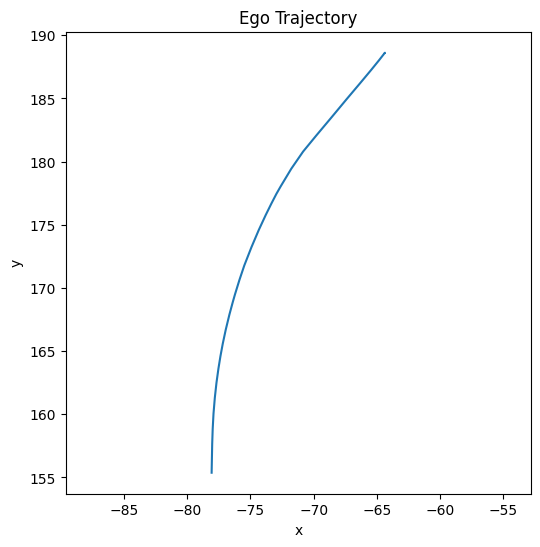

In [36]:
xs = df["pos_global"].apply(lambda x: x[0])
ys = df["pos_global"].apply(lambda x: x[1])

plt.figure(figsize=(6, 6))
plt.plot(xs, ys)
plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ego Trajectory")
plt.show()

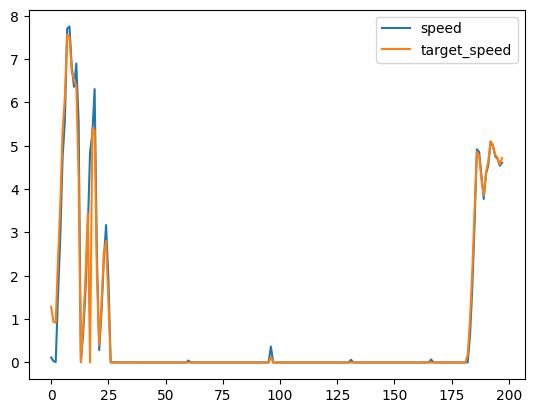

In [37]:
plt.plot(df["speed"], label="speed")
plt.plot(df["target_speed"], label="target_speed")
plt.legend()

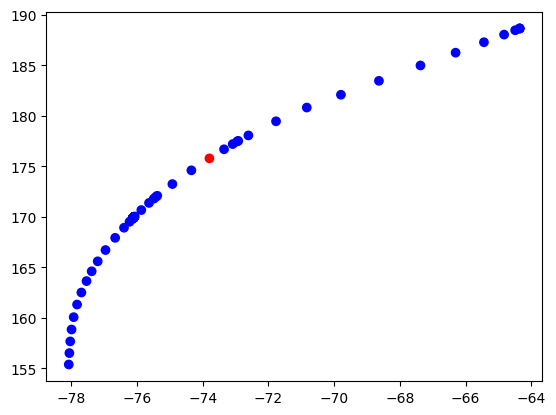

In [38]:
colors = df["vehicle_hazard"].map({True:"red", False:"blue"})

plt.scatter(xs, ys, c=colors)

## BEV Semantics

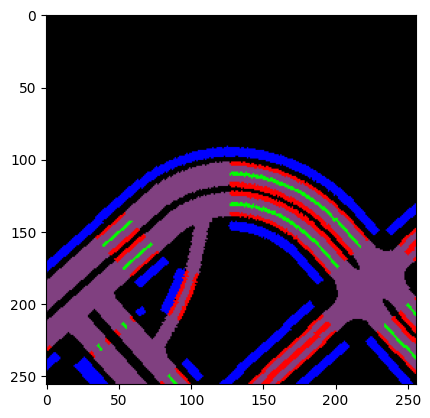

In [39]:
test_img_path = os.path.join(TRAINING_DATA_ROOT, 'bev_semantics', '0000.png')
mask = np.array(Image.open(test_img_path))
rgb = visualize_semantic_mask(mask)
plt.imshow(rgb)

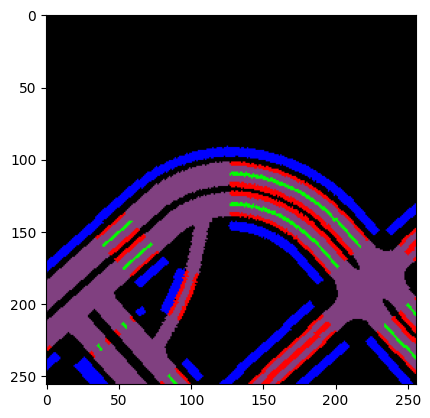

In [40]:
test_img_path = os.path.join(TRAINING_DATA_ROOT, 'bev_semantics_augmented', '0000.png')
mask = np.array(Image.open(test_img_path))
rgb = visualize_semantic_mask(mask)
plt.imshow(rgb)

## lidar viz

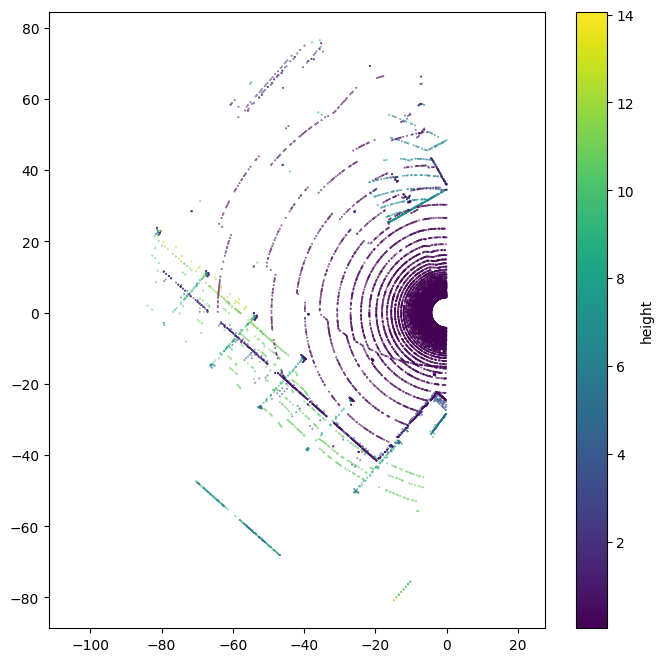

In [42]:
test_lidar_path = os.path.join(TRAINING_DATA_ROOT, "lidar", "0000.laz")
las = laspy.read(test_lidar_path)

x = las.x
y = las.y
z = las.z

plt.figure(figsize=(8,8))
plt.scatter(x, y, s=0.1, c=z)
plt.axis("equal")
plt.colorbar(label="height")
plt.show()

## box, RGB, depth, Semantic

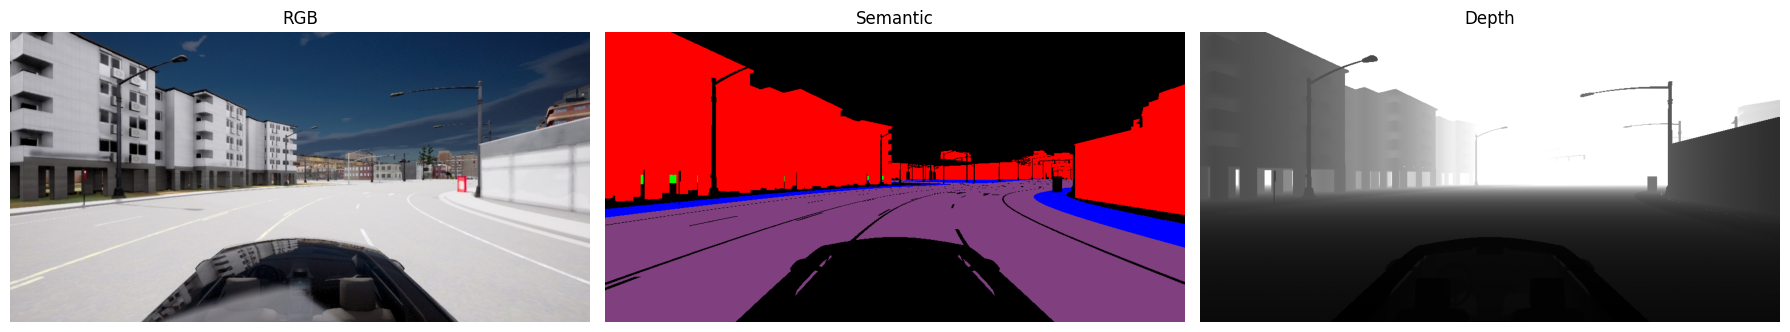

In [43]:
visualize_sample(0, TRAINING_DATA_ROOT)

In [44]:
boxes = get_gz_json(os.path.join(TRAINING_DATA_ROOT, "boxes", "0000.json.gz"))
rgb_path = os.path.join(TRAINING_DATA_ROOT, "rgb", "0000.jpg")

## records/results json

In [45]:
records = get_gz_json(os.path.join(TRAINING_DATA_ROOT, "records.json.gz"))
results = get_gz_json(os.path.join(TRAINING_DATA_ROOT, "results.json.gz"))

print(records)
print(results)

{'meta_data': {'index': 'Town03_Scenario3_3_route0_11_08_19_10_56', 'town': 'Carla/Maps/Town03'}, 'states': [], 'lights': [], 'route': [], 'ego_actions': [], 'adv_actions': []}
{'timestamp': 'Town03_Scenario3_3_route0_11_08_19_10_56', 'index': 0, 'route_id': 'RouteScenario_3_rep0', 'status': 'Completed', 'num_infractions': 2, 'infractions': {'collisions_layout': [], 'collisions_pedestrian': [], 'collisions_vehicle': [], 'red_light': [], 'stop_infraction': [], 'outside_route_lanes': [], 'min_speed_infractions': ["Average speed is 71.39% of the surrounding traffic's one", "Average speed is 8.24% of the surrounding traffic's one"], 'yield_emergency_vehicle_infractions': [], 'scenario_timeouts': [], 'route_dev': [], 'vehicle_blocked': [], 'route_timeout': []}, 'scores': {'score_route': 100, 'score_penalty': 0.662517, 'score_composed': 66.251728}, 'meta': {'route_length': 44.065, 'duration_game': 49.45, 'duration_system': 251.326}}


# Inference Results

## results_json

In [49]:
sample_route = "bench2drive220_route77_05_19_19_08_33"
json_path = os.path.join(BENCH_ROOT, f"{sample_route}/records.json.gz")
results = get_gz_json(json_path)
pprint(results)

{'adv_actions': [{'brake': [[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0]]],
                  'steer': [[[0.013420202769339085],
                             [0.0133797787129879],
                             [0.013408664613962173],
                             [0.00043982735951431096],
                             [0.0],
                             [0.0]]],
                  'throttle': [[[0.8500000238418579],
                                [0.8500000238418579],
                                [0.8500000238418579],
                                [0.8500000238418579],
                                [0.0],
                                [0.0]]]},
                 {'brake': [[[0.0], [0.0], [0.0], [0.0], [0.0]]],
                  'steer': [[[0.010238339193165302],
                             [0.010503827594220638],
                             [0.0],
                             [0.0],
                             [0.0]]],
                  'throttle': [[[0.8500000238418579],
        

## Attention mass inside GT bounding boxes

sample frame GT attention mass: 0.01620040461421013


,box_index,class,object_id,x1,y1,x2,y2,box_area_px,attention_mass
0,0,car,51869,492,270,544,310,2080,0.015245
1,1,car,51860,505,264,528,283,437,0.003315


frames evaluated: 67964
boxes evaluated: 583261


,route,frame,n_gt_boxes,gt_attention_mass,gt_attention_percent,mean_box_attention_mass,max_box_attention_mass,attention_path,box_path
0,bench2drive220_route0_05_19_07_11_15,0005,5,0.064621,6.462096,0.016849,0.044636,carla_garage/results/bench2drive220/bench2driv...,carla_garage/results/bench2drive220/bench2driv...
1,bench2drive220_route0_05_19_07_11_15,0006,5,0.065569,6.556918,0.017090,0.044762,carla_garage/results/bench2drive220/bench2driv...,carla_garage/results/bench2drive220/bench2driv...
2,bench2drive220_route0_05_19_07_11_15,0007,5,0.065261,6.526124,0.017060,0.044485,carla_garage/results/bench2drive220/bench2driv...,carla_garage/results/bench2drive220/bench2driv...
3,bench2drive220_route0_05_19_07_11_15,0008,5,0.065650,6.564984,0.017140,0.044735,carla_garage/results/bench2drive220/bench2driv...,carla_garage/results/bench2drive220/bench2driv...
4,bench2drive220_route0_05_19_07_11_15,0009,5,0.066144,6.614435,0.017273,0.044939,carla_garage/results/bench2drive220/bench2driv...,carla_garage/results/bench2drive220/bench2driv...


,gt_attention_mass,gt_attention_percent,n_gt_boxes
count,67964.000000,67964.000000,67964.000000
mean,0.198725,19.872547,8.581911
std,0.121252,12.125249,4.675263
min,0.000000,0.000000,0.000000
25%,0.100196,10.019569,4.000000
50%,0.196310,19.630981,8.000000
75%,0.293653,29.365317,13.000000
max,0.603948,60.394830,19.000000


,route,frames,mean_gt_attention_mass,median_gt_attention_mass,mean_gt_attention_percent,mean_gt_boxes
4,bench2drive220_route103_05_19_22_32_39,4688,0.395891,0.406268,39.589108,15.296715
28,bench2drive220_route25_05_19_12_09_15,1034,0.368690,0.394291,36.868972,14.221470
14,bench2drive220_route12_05_19_09_41_53,4651,0.320403,0.330983,32.040276,13.491292
7,bench2drive220_route106_05_20_00_14_26,4936,0.306263,0.318455,30.626293,12.116694
21,bench2drive220_route19_05_19_11_15_17,1011,0.291100,0.321817,29.110049,13.318497
65,bench2drive220_route59_05_19_16_43_39,1015,0.283402,0.289029,28.340157,15.440394
50,bench2drive220_route45_05_19_14_25_41,4456,0.277707,0.278117,27.770747,10.710952
70,bench2drive220_route63_05_19_17_11_03,337,0.272716,0.274184,27.271557,8.655786
108,bench2drive220_route98_05_19_22_02_01,714,0.233221,0.260725,23.322102,10.973389
24,bench2drive220_route21_05_19_11_36_39,1230,0.229861,0.268725,22.986117,8.239024


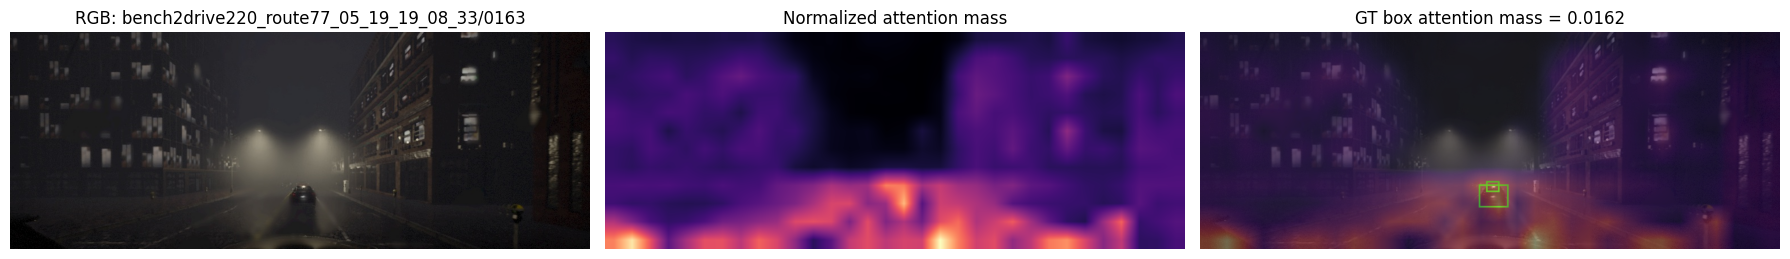

In [54]:
# Quick visual sanity check on the route/frame currently open in the IDE.
sample_route = "bench2drive220_route77_05_19_19_08_33"
sample_frame_mass, sample_box_df = plot_attention_metric_sample(route_name=sample_route, frame="0163")
print("sample frame GT attention mass:", sample_frame_mass)
display(sample_box_df)

# Evaluate the full bench2drive220 result folder. Set max_routes/max_frames_per_route while iterating.
frame_attention_df, box_attention_df = evaluate_attention_metric(
    BENCH_ROOT,
    max_routes=None,
    max_frames_per_route=None,
    class_filter=None,
    normalization="probability",
)

print("frames evaluated:", len(frame_attention_df))
print("boxes evaluated:", len(box_attention_df))
display(frame_attention_df.head())

display(
    frame_attention_df[["gt_attention_mass", "gt_attention_percent", "n_gt_boxes"]]
    .describe()
)

display(
    frame_attention_df.groupby("route", as_index=False)
    .agg(
        frames=("frame", "count"),
        mean_gt_attention_mass=("gt_attention_mass", "mean"),
        median_gt_attention_mass=("gt_attention_mass", "median"),
        mean_gt_attention_percent=("gt_attention_percent", "mean"),
        mean_gt_boxes=("n_gt_boxes", "mean"),
    )
    .sort_values("mean_gt_attention_mass", ascending=False)
    .head(20)
)

In [55]:
box_attention_df.head()

,box_index,class,object_id,x1,y1,x2,y2,box_area_px,attention_mass,route,frame
0,0,car,3855,488,269,536,307,1824,0.013557,bench2drive220_route0_05_19_07_11_15,0005
1,1,car,3854,498,261,526,281,560,0.003925,bench2drive220_route0_05_19_07_11_15,0005
2,2,static,3800,420,267,480,304,2220,0.015107,bench2drive220_route0_05_19_07_11_15,0005
3,3,static,3744,364,264,466,332,6936,0.044636,bench2drive220_route0_05_19_07_11_15,0005
4,4,static,3743,446,264,487,291,1107,0.007021,bench2drive220_route0_05_19_07_11_15,0005


In [56]:
class_attention_mean = (
    box_attention_df
    .groupby("class")["attention_mass"]
    .mean()
    .reset_index()
    .sort_values("attention_mass", ascending=False)
)

class_attention_mean

,class,attention_mass
4,traffic_light,0.041579
0,car,0.034828
3,stop_sign,0.034025
1,speed_limit,0.022347
2,static,0.013573
5,walker,0.002896


In [59]:
box_attention_df["attention_density"] = (
    box_attention_df["attention_mass"] / box_attention_df["box_area_px"] * 1e6
)

class_attention_density = (
    box_attention_df
    .groupby("class")["attention_density"]
    .mean()
    .reset_index()
    .sort_values("attention_density", ascending=False)
)

class_attention_stats = (
    box_attention_df
    .groupby("class")["attention_density"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

class_attention_stats

,class,mean,std,count
2,static,6.949264,1.687671,34553
5,walker,6.278085,0.839062,3268
0,car,5.863651,1.250059,336591
3,stop_sign,5.819718,1.240975,37120
4,traffic_light,5.557434,1.039775,75653
1,speed_limit,5.325527,1.192841,96076


In [61]:
class_box_area_mean = (
    box_attention_df
    .groupby("class")["box_area_px"]
    .mean()
    .reset_index()
    .sort_values("box_area_px", ascending=False)
)

class_box_area_mean

,class,box_area_px
4,traffic_light,7578.857891
0,car,6349.610180
3,stop_sign,6207.026940
1,speed_limit,4492.689766
2,static,2310.866292
5,walker,465.640453


## Collision cases

In [60]:
DEBUG_RESULTS_PATH = BENCH_ROOT / "debug_results.json"
COLLISION_WINDOW_RADIUS = 10

collision_events_df, collision_window_frame_df, collision_window_box_df = evaluate_collision_attention_windows(
    bench_root=BENCH_ROOT,
    debug_json_path=DEBUG_RESULTS_PATH,
    window_radius=COLLISION_WINDOW_RADIUS,
    normalization="probability",
)

print("collision events:", len(collision_events_df))
print("collision-window frames evaluated:", len(collision_window_frame_df))
print("collision-window boxes evaluated:", len(collision_window_box_df))

display(collision_events_df.head(20))
display(collision_window_frame_df.head(20))

display(
    collision_window_frame_df[[
        "gt_attention_mass",
        "gt_attention_percent",
        "collision_actor_attention_mass",
        "collision_actor_attention_percent",
        "relative_frame",
    ]].describe()
)

collision_attention_summary_df = summarize_collision_attention(collision_window_frame_df)
display(collision_attention_summary_df.head(30))

# Mean temporal profile around collision frame. relative_frame=0 is the estimated collision frame.
display(
    collision_window_frame_df.groupby("relative_frame", as_index=False)
    .agg(
        events=("event_index", "nunique"),
        mean_gt_attention_mass=("gt_attention_mass", "mean"),
        mean_collision_actor_attention_mass=("collision_actor_attention_mass", "mean"),
        actor_visible_rate=("collision_actor_visible", "mean"),
    )
)

collision events: 27
collision-window frames evaluated: 522
collision-window boxes evaluated: 3455


,object_type,object_id,collision_x,collision_y,collision_z,collision_message,route,route_index,route_id,collision_kind,collision_index_in_kind,score_composed,duration_game,event_index,estimated_collision_frame,frame_source,actor_observed_frames
0,vehicle.audi.tt,14973,3070.693,6262.108,370.521,Agent collided against object with type=vehicl...,bench2drive220_route3_05_19_07_30_08,3,RouteScenario_1792_rep0,collisions_vehicle,0,58.749000,15.45,0,0116,min_actor_distance,304
1,vehicle.mercedes.coupe_2020,18689,1176.579,5375.946,370.873,Agent collided against object with type=vehicl...,bench2drive220_route4_05_19_07_35_35,4,RouteScenario_1825_rep0,collisions_vehicle,0,51.798495,106.95,1,0294,min_actor_distance,1842
2,vehicle.audi.tt,33481,2536.403,2073.047,356.946,Agent collided against object with type=vehicl...,bench2drive220_route8_05_19_08_28_32,8,RouteScenario_2050_rep0,collisions_vehicle,0,60.000000,13.75,2,0178,min_actor_distance,31
3,vehicle.audi.tt,40889,-1381.157,5321.996,376.652,Agent collided against object with type=vehicl...,bench2drive220_route10_05_19_08_37_18,10,RouteScenario_2084_rep0,collisions_vehicle,0,54.812400,193.70,3,0136,min_actor_distance,3654
4,vehicle.audi.tt,48308,2769.961,1600.535,343.664,Agent collided against object with type=vehicl...,bench2drive220_route12_05_19_09_41_53,12,RouteScenario_2091_rep0,collisions_vehicle,0,50.623800,232.80,4,2614,min_actor_distance,3438
5,vehicle.chevrolet.impala,52017,1985.641,2171.578,362.191,Agent collided against object with type=vehicl...,bench2drive220_route13_05_19_10_44_15,13,RouteScenario_2115_rep0,collisions_vehicle,0,60.000000,14.40,5,0287,fallback_last_attention_frame,0
6,vehicle.nissan.patrol_2021,70507,-1471.030,3917.948,363.743,Agent collided against object with type=vehicl...,bench2drive220_route18_05_19_11_09_27,18,RouteScenario_2164_rep0,collisions_vehicle,0,35.886600,17.70,6,0253,min_actor_distance,157
7,vehicle.nissan.patrol_2021,70507,-1471.030,3917.948,363.743,Agent collided against object with type=vehicl...,bench2drive220_route18_05_19_11_09_27,18,RouteScenario_2164_rep0,collisions_vehicle,1,35.886600,17.70,7,0253,min_actor_distance,157
8,vehicle.mini.cooper_s_2021,74322,920.595,3684.278,370.789,Agent collided against object with type=vehicl...,bench2drive220_route19_05_19_11_15_17,19,RouteScenario_2201_rep0,collisions_vehicle,0,51.439200,50.80,8,1015,fallback_last_attention_frame,0
9,vehicle.dodge.charger_2020,89119,-2222.489,6376.773,378.050,Agent collided against object with type=vehicl...,bench2drive220_route23_05_19_11_59_51,23,RouteScenario_2283_rep0,collisions_vehicle,0,60.000000,15.85,9,0065,min_actor_distance,30


,event_index,route,route_id,collision_kind,object_type,object_id,estimated_collision_frame,frame,relative_frame,n_gt_boxes,gt_attention_mass,gt_attention_percent,collision_actor_attention_mass,collision_actor_attention_percent,collision_actor_visible,frame_source
0,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0106,-10,3,0.280655,28.065503,0.067088,6.708770,True,min_actor_distance
1,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0107,-9,3,0.335538,33.553752,0.073496,7.349637,True,min_actor_distance
2,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0108,-8,3,0.348640,34.864032,0.074333,7.433289,True,min_actor_distance
3,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0109,-7,3,0.345716,34.571570,0.075792,7.579228,True,min_actor_distance
4,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0110,-6,3,0.344707,34.470659,0.076470,7.647046,True,min_actor_distance
5,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0111,-5,3,0.347002,34.700209,0.077393,7.739251,True,min_actor_distance
6,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0112,-4,3,0.351623,35.162270,0.077855,7.785479,True,min_actor_distance
7,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0113,-3,3,0.363860,36.385971,0.079015,7.901479,True,min_actor_distance
8,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0114,-2,3,0.362161,36.216110,0.080634,8.063361,True,min_actor_distance
9,0,bench2drive220_route3_05_19_07_30_08,RouteScenario_1792_rep0,collisions_vehicle,vehicle.audi.tt,14973,0116,0115,-1,3,0.354501,35.450125,0.077752,7.775246,True,min_actor_distance


,gt_attention_mass,gt_attention_percent,collision_actor_attention_mass,collision_actor_attention_percent,relative_frame
count,522.000000,522.000000,522.000000,522.000000,522.000000
mean,0.197209,19.720923,0.101255,10.125543,-0.498084
std,0.100898,10.089832,0.088099,8.809911,6.005515
min,0.000000,0.000000,0.000000,0.000000,-10.000000
25%,0.128848,12.884835,0.000000,0.000000,-6.000000
50%,0.218989,21.898937,0.114313,11.431284,-1.000000
75%,0.265327,26.532670,0.181386,18.138625,5.000000
max,0.429793,42.979255,0.272829,27.282867,10.000000


,event_index,route,object_id,object_type,collision_kind,estimated_collision_frame,window_frames,mean_gt_attention_mass,max_gt_attention_mass,at_collision_gt_attention_mass,mean_collision_actor_attention_mass,max_collision_actor_attention_mass,at_collision_actor_attention_mass,actor_visible_frames
23,23,bench2drive220_route95_05_19_21_41_43,28535,vehicle.lincoln.mkz_2020,collisions_vehicle,0083,21,0.254505,0.275204,0.250278,0.252369,0.272829,0.248047,21
25,25,bench2drive220_route106_05_20_00_14_26,76641,vehicle.nissan.patrol_2021,collisions_vehicle,4719,21,0.275300,0.279353,0.278215,0.228619,0.231519,0.230825,21
20,20,bench2drive220_route74_05_19_18_53_15,37731,vehicle.dodge.charger_police_2020,collisions_vehicle,0153,21,0.129081,0.247176,0.231179,0.122563,0.245253,0.224018,11
6,6,bench2drive220_route18_05_19_11_09_27,70507,vehicle.nissan.patrol_2021,collisions_vehicle,0253,21,0.187348,0.300448,0.300448,0.078261,0.214990,0.214990,11
7,7,bench2drive220_route18_05_19_11_09_27,70507,vehicle.nissan.patrol_2021,collisions_vehicle,0253,21,0.187348,0.300448,0.300448,0.078261,0.214990,0.214990,11
21,21,bench2drive220_route85_05_19_20_13_32,89533,vehicle.ford.mustang,collisions_vehicle,0149,21,0.311316,0.346256,0.326273,0.114716,0.228956,0.211959,11
16,16,bench2drive220_route46_05_19_15_31_14,29665,vehicle.ford.mustang,collisions_vehicle,0145,16,0.129296,0.255762,0.236124,0.092378,0.226398,0.200224,11
14,14,bench2drive220_route42_05_19_14_07_09,14826,vehicle.audi.tt,collisions_vehicle,0139,21,0.251266,0.334810,0.229136,0.194810,0.201715,0.189304,21
22,22,bench2drive220_route94_05_19_21_33_43,23791,vehicle.dodge.charger_2020,collisions_vehicle,0062,21,0.174040,0.232060,0.217958,0.108198,0.221597,0.184340,11
9,9,bench2drive220_route23_05_19_11_59_51,89119,vehicle.dodge.charger_2020,collisions_vehicle,0065,21,0.126371,0.240660,0.194891,0.113161,0.230034,0.181408,11


,relative_frame,events,mean_gt_attention_mass,mean_collision_actor_attention_mass,actor_visible_rate
0,-10,27,0.204364,0.117817,0.851852
1,-9,27,0.209079,0.120891,0.851852
2,-8,27,0.212172,0.124206,0.851852
3,-7,27,0.214131,0.127320,0.851852
4,-6,27,0.215949,0.129293,0.851852
5,-5,27,0.215854,0.129823,0.851852
6,-4,27,0.217450,0.131354,0.851852
7,-3,27,0.218920,0.133370,0.851852
8,-2,27,0.217691,0.131169,0.851852
9,-1,27,0.215899,0.130368,0.851852


## check collision Videos

In [82]:
def make_video(route_id, output_path, s_frame, e_frame, fps=20):
    folder1 = os.path.join(BENCH_ROOT, f"{route_id}/model_results")
    folder2 = os.path.join(BENCH_ROOT, f"{route_id}/sensor_data/attention_overlay")

    images1 = get_sorted_images(folder1)
    images2 = get_sorted_images(folder2)
    num_frames = len(images1)

    if num_frames == 0:
        raise ValueError("이미지가 없습니다.")

    # 첫 이미지 읽기
    img1 = cv2.imread(images1[0])
    img2 = cv2.imread(images2[0])

    # 높이 맞추기
    height = min(img1.shape[0], img2.shape[0])
    img1 = resize_keep_ratio(img1, height)
    img2 = resize_keep_ratio(img2, height)

    # 최종 영상 크기
    video_width = img1.shape[1] + img2.shape[1]
    video_height = height

    # VideoWriter
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(
        output_path,
        fourcc,
        fps,
        (video_width, video_height)
    )

    for i in range(max(0, s_frame), min(num_frames, e_frame)):

        frame1 = cv2.imread(images1[i])
        frame2 = cv2.imread(images2[i])

        frame1 = resize_keep_ratio(frame1, height)
        frame2 = resize_keep_ratio(frame2, height)

        # 가로 concat
        combined = np.hstack((frame1, frame2))
        writer.write(combined)

    writer.release()

In [83]:
save_path = "/home/ec2-user/AD_challenge/collision_videos"
os.makedirs(save_path, exist_ok=True)

for row in tqdm(collision_events_df.itertuples()):
    route_id = row.route
    print(row)
    frame = int(row.estimated_collision_frame)
    s_frame = frame - 120
    e_frame = frame + 120
    output_path = os.path.join(save_path, f"{route_id}_collision_{row.event_index}.mp4")
    make_video(route_id, output_path, s_frame, e_frame)

0it [00:00, ?it/s]

Pandas(Index=0, object_type='vehicle.audi.tt', object_id=14973, collision_x=3070.693, collision_y=6262.108, collision_z=370.521, collision_message='Agent collided against object with type=vehicle.audi.tt and id=14973 at (x=3070.693, y=6262.108, z=370.521)', route='bench2drive220_route3_05_19_07_30_08', route_index=3, route_id='RouteScenario_1792_rep0', collision_kind='collisions_vehicle', collision_index_in_kind=0, score_composed=58.749, duration_game=15.45, event_index=0, estimated_collision_frame='0116', frame_source='min_actor_distance', actor_observed_frames=304)


1it [00:09,  9.03s/it]

Pandas(Index=1, object_type='vehicle.mercedes.coupe_2020', object_id=18689, collision_x=1176.579, collision_y=5375.946, collision_z=370.873, collision_message='Agent collided against object with type=vehicle.mercedes.coupe_2020 and id=18689 at (x=1176.579, y=5375.946, z=370.873)', route='bench2drive220_route4_05_19_07_35_35', route_index=4, route_id='RouteScenario_1825_rep0', collision_kind='collisions_vehicle', collision_index_in_kind=0, score_composed=51.798495, duration_game=106.95, event_index=1, estimated_collision_frame='0294', frame_source='min_actor_distance', actor_observed_frames=1842)


2it [00:16,  8.22s/it]

...

25it [02:54,  7.35s/it]

Pandas(Index=25, object_type='vehicle.nissan.patrol_2021', object_id=76641, collision_x=1360.451, collision_y=5579.461, collision_z=369.598, collision_message='Agent collided against object with type=vehicle.nissan.patrol_2021 and id=76641 at (x=1360.451, y=5579.461, z=369.598)', route='bench2drive220_route106_05_20_00_14_26', route_index=106, route_id='RouteScenario_4669_rep0', collision_kind='collisions_vehicle', collision_index_in_kind=0, score_composed=38.40144, duration_game=247.05, event_index=25, estimated_collision_frame='4719', frame_source='min_actor_distance', actor_observed_frames=4697)


26it [03:02,  7.67s/it]

Pandas(Index=26, object_type='vehicle.audi.tt', object_id=80354, collision_x=2203.023, collision_y=4873.993, collision_z=365.312, collision_message='Agent collided against object with type=vehicle.audi.tt and id=80354 at (x=2203.023, y=4873.993, z=365.312)', route='bench2drive220_route107_05_20_01_33_55', route_index=107, route_id='RouteScenario_4683_rep0', collision_kind='collisions_vehicle', collision_index_in_kind=0, score_composed=60.0, duration_game=13.55, event_index=26, estimated_collision_frame='0188', frame_source='min_actor_distance', actor_observed_frames=54)


27it [03:09,  7.01s/it]
